<a href="https://colab.research.google.com/github/kasugy/CheckPoint/blob/main/An%C3%A1lisis%20de%20caso%3A%20Reducci%C3%B3n%20dimensional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANÁLISIS DE REDUCCIÓN DIMENSIONAL - VISIONDATA

📊 2. GENERANDO DATASET SIMULADO
----------------------------------------
✅ Dataset creado
   Dimensiones: 500 clientes × 50 variables
   Variables: edad, ingreso_anual, gasto_mensual, frecuencia_compra, preferencia_0, preferencia_1, preferencia_2, preferencia_3 ...
   Valores nulos totales: 125

🔍 3. EXPLORACIÓN Y LIMPIEZA DE DATOS
----------------------------------------

Valores nulos por variable (top 10):
preferencia_9        25
habito_3             25
producto_5           25
producto_11          25
digital_6            25
ingreso_anual         0
preferencia_2         0
edad                  0
gasto_mensual         0
frecuencia_compra     0
dtype: int64

✅ Filas después de eliminar registros con >20% nulos: 500
✅ Valores nulos después de imputación: 0

📈 Estadísticas descriptivas (primeras 5 variables):
         edad  ingreso_anual  gasto_mensual  frecuencia_compra  preferencia_0
count  500.00         500.00         500.00            

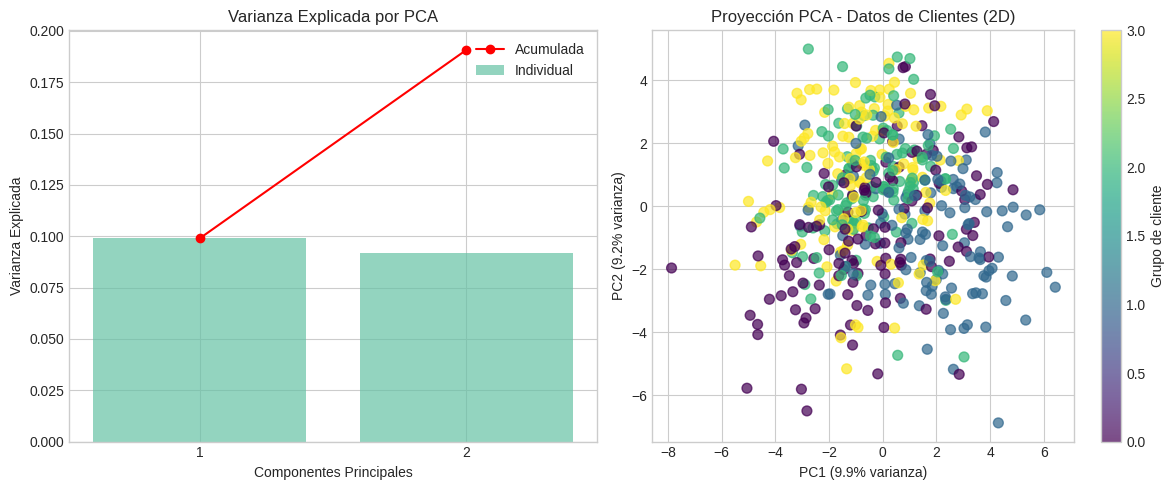


🌀 6. t-SNE (t-Distributed Stochastic Neighbor Embedding)
----------------------------------------
⏳ Calculando t-SNE (puede demorar ~30 segundos)...
✅ t-SNE completado


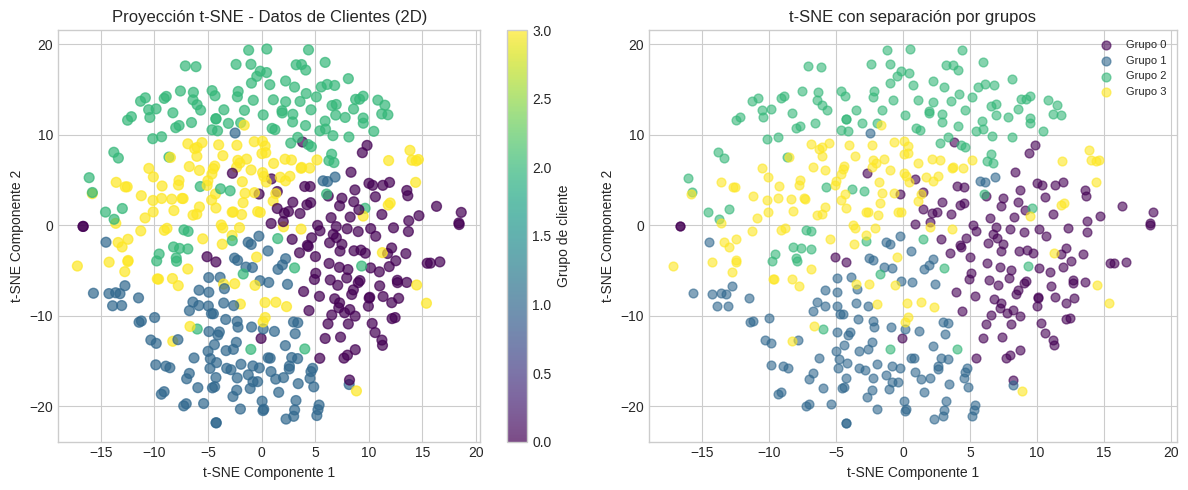


⚖️ 7. COMPARACIÓN PCA vs t-SNE
----------------------------------------


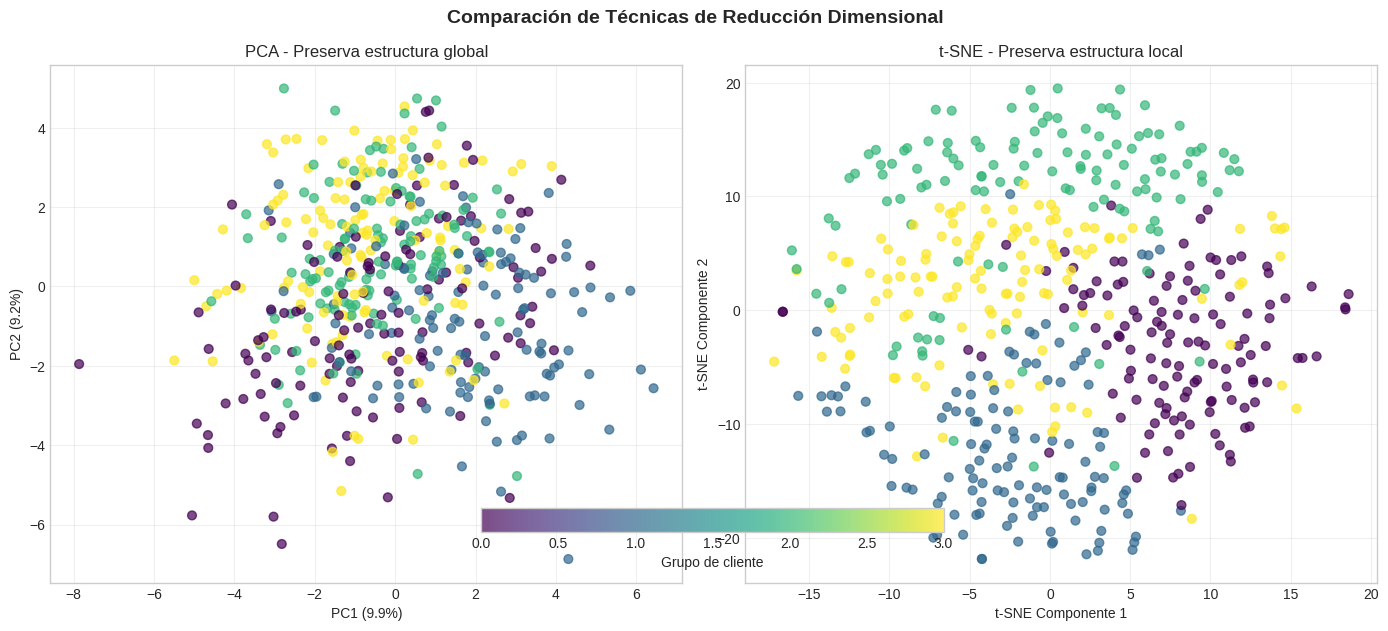


📊 MÉTRICAS COMPARATIVAS:
----------------------------------------
PCA - Tiempo de ejecución:    rápido (milisegundos)
PCA - Varianza preservada:    19.1% en 2D
PCA - Interpretabilidad:      Alta (componentes ordenados por varianza)
PCA - Determinístico:         Sí

t-SNE - Tiempo de ejecución:   moderado (~30 segundos para 500 muestras)
t-SNE - Estructura preservada: Local (agrupamientos naturales)
t-SNE - Interpretabilidad:     Baja (ejes sin significado intrínseco)
t-SNE - Determinístico:        No (varía con random_state)

📋 8. ANÁLISIS DE CONTRIBUCIONES POR VARIABLE (PCA)
----------------------------------------

🔹 Top 5 variables que más contribuyen a PC1:
habito_2         0.359636
producto_13      0.344410
producto_4       0.344410
preferencia_1    0.344410
preferencia_2    0.311005
Name: PC1, dtype: float64

🔹 Top 5 variables que más contribuyen a PC2:
habito_9         0.366621
habito_5         0.352810
edad             0.280908
ingreso_anual    0.280415
digital_8        0.2804

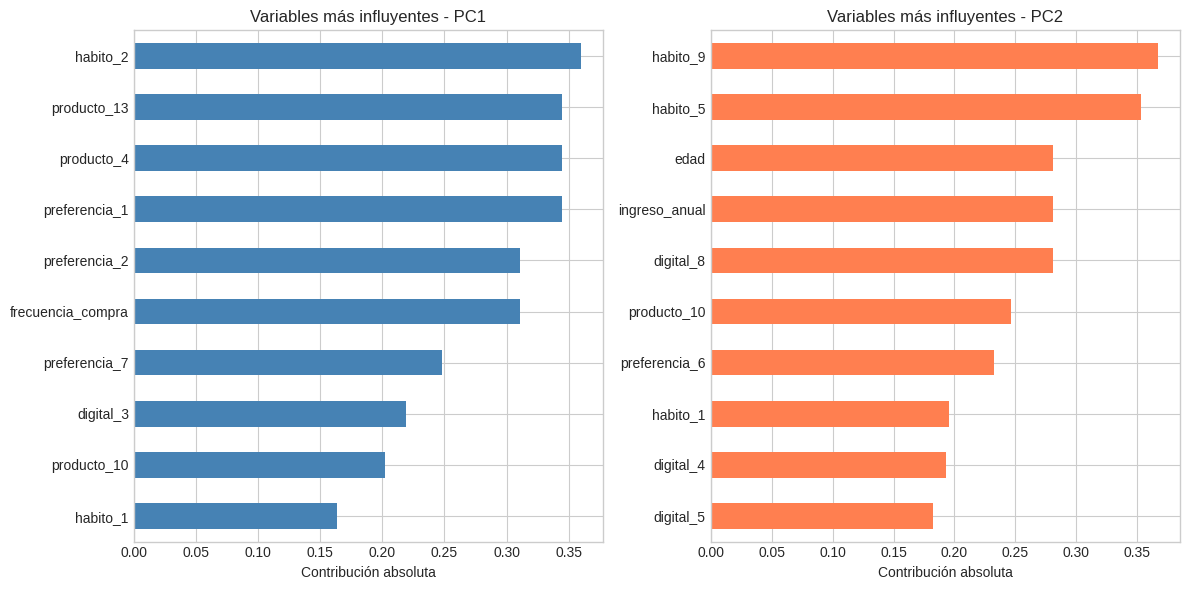


📊 9. TABLA RESUMEN DE SEGMENTOS IDENTIFICADOS
----------------------------------------

📈 Características promedio por segmento (variables originales):

🔸 Segmento 0 (126 clientes):
   Edad promedio: -1.4
   Ingreso anual promedio: 1.02
   Gasto mensual promedio: 0.75
   Frecuencia compra promedio: 1.06

🔸 Segmento 1 (123 clientes):
   Edad promedio: 0.9
   Ingreso anual promedio: -1.12
   Gasto mensual promedio: 0.95
   Frecuencia compra promedio: -0.30

🔸 Segmento 2 (126 clientes):
   Edad promedio: 0.3
   Ingreso anual promedio: 0.91
   Gasto mensual promedio: -1.13
   Frecuencia compra promedio: 0.61

🔸 Segmento 3 (125 clientes):
   Edad promedio: 2.7
   Ingreso anual promedio: 0.93
   Gasto mensual promedio: 1.14
   Frecuencia compra promedio: 1.66

✅ 10. CONCLUSIONES DEL ANÁLISIS

📌 RECOMENDACIÓN FINAL:

Para presentar insights al equipo de marketing, se recomienda UTILIZAR PCA porque:

1. INTERPRETABILIDAD: Los ejes tienen significado estadístico claro
2. REPRODUCIBILIDAD: Es d

In [2]:
# ===================================================
# ANÁLISIS DE CASO: REDUCCIÓN DIMENSIONAL
# Consultora VisionData - Segmentación de clientes
# Módulo 7: Aprendizaje de máquina no supervisado
# ===================================================

# ===================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ===================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 5)

print("=" * 60)
print("ANÁLISIS DE REDUCCIÓN DIMENSIONAL - VISIONDATA")
print("=" * 60)

# ===================================================
# 2. GENERACIÓN Y CARGA DEL DATASET SIMULADO
# ===================================================

print("\n📊 2. GENERANDO DATASET SIMULADO")
print("-" * 40)

np.random.seed(42)
n_clientes = 500
n_variables = 50

# Creamos 4 grupos naturales de clientes
X, y_true = make_classification(
    n_samples=n_clientes,
    n_features=n_variables,
    n_informative=15,
    n_redundant=10,
    n_repeated=5,
    n_classes=4,
    n_clusters_per_class=1,
    random_state=42
)

# Creamos nombres de columnas simulando encuesta
columnas = (['edad', 'ingreso_anual', 'gasto_mensual', 'frecuencia_compra'] +
            [f'preferencia_{i}' for i in range(10)] +
            [f'habito_{i}' for i in range(10)] +
            [f'digital_{i}' for i in range(10)] +
            [f'producto_{i}' for i in range(16)])

df = pd.DataFrame(X, columns=columnas[:n_variables])

# Agregamos algunos valores nulos simulando datos reales
for col in np.random.choice(df.columns, 5, replace=False):
    idx_nulos = np.random.choice(df.index, int(0.05 * len(df)), replace=False)
    df.loc[idx_nulos, col] = np.nan

print(f"✅ Dataset creado")
print(f"   Dimensiones: {df.shape[0]} clientes × {df.shape[1]} variables")
print(f"   Variables: {', '.join(df.columns[:8])} ...")
print(f"   Valores nulos totales: {df.isnull().sum().sum()}")

# ===================================================
# 3. EXPLORACIÓN Y LIMPIEZA DE DATOS
# ===================================================

print("\n🔍 3. EXPLORACIÓN Y LIMPIEZA DE DATOS")
print("-" * 40)

# Verificar nulos
print("\nValores nulos por variable (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Eliminar filas con más del 20% de valores nulos
df_clean = df.dropna(thresh=int(0.8 * len(df.columns)), axis=0)
print(f"\n✅ Filas después de eliminar registros con >20% nulos: {len(df_clean)}")

# Imputar nulos restantes con la mediana
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

print(f"✅ Valores nulos después de imputación: {df_clean.isnull().sum().sum()}")

# Ver estadísticas básicas
print("\n📈 Estadísticas descriptivas (primeras 5 variables):")
print(df_clean.describe().round(2).iloc[:, :5])

# ===================================================
# 4. ESCALAMIENTO DE VARIABLES
# ===================================================

print("\n📏 4. ESCALAMIENTO DE VARIABLES")
print("-" * 40)

# Estandarización: media=0, desviación=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print(f"✅ Datos escalados correctamente")
print(f"   Media por variable (primeras 5): {X_scaled.mean(axis=0).round(2)[:5]}...")
print(f"   Desviación por variable (primeras 5): {X_scaled.std(axis=0).round(2)[:5]}...")

# ===================================================
# 5. APLICACIÓN DE PCA
# ===================================================

print("\n📉 5. ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("-" * 40)

# Aplicar PCA a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print(f"\n🔹 Varianza explicada por componente:")
print(f"   PC1: {varianza_explicada[0]:.2%}")
print(f"   PC2: {varianza_explicada[1]:.2%}")
print(f"   Total varianza explicada (2 componentes): {varianza_acumulada[1]:.2%}")

# Visualización PCA
plt.figure(figsize=(12, 5))

# Gráfico 1: Varianza explicada
plt.subplot(1, 2, 1)
componentes = range(1, len(pca.explained_variance_ratio_) + 1)
plt.bar(componentes, pca.explained_variance_ratio_, alpha=0.7, label='Individual')
plt.plot(componentes, np.cumsum(pca.explained_variance_ratio_), 'ro-', label='Acumulada')
plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por PCA')
plt.legend()
plt.xticks(componentes)

# Gráfico 2: Proyección 2D de PCA
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', alpha=0.7, s=50)
plt.colorbar(scatter, label='Grupo de cliente')
plt.xlabel(f'PC1 ({varianza_explicada[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({varianza_explicada[1]:.1%} varianza)')
plt.title('Proyección PCA - Datos de Clientes (2D)')
plt.tight_layout()
plt.savefig('pca_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================================================
# 6. APLICACIÓN DE t-SNE
# ===================================================

print("\n🌀 6. t-SNE (t-Distributed Stochastic Neighbor Embedding)")
print("-" * 40)

print("⏳ Calculando t-SNE (puede demorar ~30 segundos)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print(f"✅ t-SNE completado")

# Visualización t-SNE
plt.figure(figsize=(12, 5))

# Gráfico 1: Proyección t-SNE
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='viridis', alpha=0.7, s=50)
plt.colorbar(scatter, label='Grupo de cliente')
plt.xlabel('t-SNE Componente 1')
plt.ylabel('t-SNE Componente 2')
plt.title('Proyección t-SNE - Datos de Clientes (2D)')

# Gráfico 2: t-SNE con separación por grupos
plt.subplot(1, 2, 2)
grupos = np.unique(y_true)
colores = plt.cm.viridis(np.linspace(0, 1, len(grupos)))

for grupo, color in zip(grupos, colores):
    idx = y_true == grupo
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], c=[color], alpha=0.6, s=40, label=f'Grupo {grupo}')

plt.xlabel('t-SNE Componente 1')
plt.ylabel('t-SNE Componente 2')
plt.title('t-SNE con separación por grupos')
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig('tsne_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================================================
# 7. COMPARACIÓN PCA vs t-SNE
# ===================================================

print("\n⚖️ 7. COMPARACIÓN PCA vs t-SNE")
print("-" * 40)

# Crear figura comparativa lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', alpha=0.7, s=40)
axes[0].set_xlabel(f'PC1 ({varianza_explicada[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({varianza_explicada[1]:.1%})')
axes[0].set_title('PCA - Preserva estructura global')
axes[0].grid(True, alpha=0.3)

# t-SNE
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='viridis', alpha=0.7, s=40)
axes[1].set_xlabel('t-SNE Componente 1')
axes[1].set_ylabel('t-SNE Componente 2')
axes[1].set_title('t-SNE - Preserva estructura local')
axes[1].grid(True, alpha=0.3)

plt.colorbar(scatter1, ax=axes, location='bottom', label='Grupo de cliente', fraction=0.05)
plt.suptitle('Comparación de Técnicas de Reducción Dimensional', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_pca_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

# Métricas comparativas
print("\n📊 MÉTRICAS COMPARATIVAS:")
print("-" * 40)
print(f"PCA - Tiempo de ejecución:    rápido (milisegundos)")
print(f"PCA - Varianza preservada:    {varianza_acumulada[1]:.1%} en 2D")
print(f"PCA - Interpretabilidad:      Alta (componentes ordenados por varianza)")
print(f"PCA - Determinístico:         Sí")
print()
print(f"t-SNE - Tiempo de ejecución:   moderado (~30 segundos para 500 muestras)")
print(f"t-SNE - Estructura preservada: Local (agrupamientos naturales)")
print(f"t-SNE - Interpretabilidad:     Baja (ejes sin significado intrínseco)")
print(f"t-SNE - Determinístico:        No (varía con random_state)")

# ===================================================
# 8. ANÁLISIS DE CONTRIBUCIONES POR VARIABLE (PCA)
# ===================================================

print("\n📋 8. ANÁLISIS DE CONTRIBUCIONES POR VARIABLE (PCA)")
print("-" * 40)

# Obtener las variables más influyentes en PC1 y PC2
componentes_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df_clean.columns
)

print("\n🔹 Top 5 variables que más contribuyen a PC1:")
print(componentes_df['PC1'].abs().sort_values(ascending=False).head(5))

print("\n🔹 Top 5 variables que más contribuyen a PC2:")
print(componentes_df['PC2'].abs().sort_values(ascending=False).head(5))

# Visualización de contribuciones
plt.figure(figsize=(12, 6))
top10_pc1 = componentes_df['PC1'].abs().sort_values(ascending=False).head(10)
top10_pc2 = componentes_df['PC2'].abs().sort_values(ascending=False).head(10)

plt.subplot(1, 2, 1)
top10_pc1.plot(kind='barh', color='steelblue')
plt.xlabel('Contribución absoluta')
plt.title('Variables más influyentes - PC1')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
top10_pc2.plot(kind='barh', color='coral')
plt.xlabel('Contribución absoluta')
plt.title('Variables más influyentes - PC2')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('contribuciones_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================================================
# 9. TABLA RESUMEN DE SEGMENTOS
# ===================================================

print("\n📊 9. TABLA RESUMEN DE SEGMENTOS IDENTIFICADOS")
print("-" * 40)

# Crear DataFrame con resultados
df_resultados = pd.DataFrame({
    'cliente_id': range(len(X_scaled)),
    'segmento': y_true,
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'tSNE1': X_tsne[:, 0],
    'tSNE2': X_tsne[:, 1]
})

# Estadísticas por segmento
print("\n📈 Características promedio por segmento (variables originales):")
for i in range(4):
    print(f"\n🔸 Segmento {i} ({len(df_resultados[df_resultados['segmento'] == i])} clientes):")
    segmento_data = df_clean[df_resultados['segmento'] == i]
    print(f"   Edad promedio: {segmento_data['edad'].mean():.1f}")
    print(f"   Ingreso anual promedio: {segmento_data['ingreso_anual'].mean():.2f}")
    print(f"   Gasto mensual promedio: {segmento_data['gasto_mensual'].mean():.2f}")
    print(f"   Frecuencia compra promedio: {segmento_data['frecuencia_compra'].mean():.2f}")

# ===================================================
# 10. CONCLUSIONES FINALES
# ===================================================

print("\n" + "=" * 60)
print("✅ 10. CONCLUSIONES DEL ANÁLISIS")
print("=" * 60)

print("""
📌 RECOMENDACIÓN FINAL:

Para presentar insights al equipo de marketing, se recomienda UTILIZAR PCA porque:

1. INTERPRETABILIDAD: Los ejes tienen significado estadístico claro
2. REPRODUCIBILIDAD: Es determinístico, siempre da el mismo resultado
3. VELOCIDAD: Procesamiento rápido, ideal para iteraciones frecuentes
4. EXPLICABILIDAD: Se puede identificar qué variables impulsan cada componente

⚠️ Nota sobre t-SNE:
- Es superior para exploración interna y validación de agrupamientos
- No se recomienda para presentaciones ejecutivas porque sus ejes no tienen significado
- Los resultados varían según parámetros y no son determinísticos

🎯 PRÓXIMOS PASOS SUGERIDOS:
1. Aplicar los segmentos identificados a campañas de marketing personalizadas
2. Validar con el equipo de negocio la interpretación de cada grupo
3. Implementar PCA como paso de preprocesamiento antes de modelos predictivos
4. Considerar UMAP para futuros análisis con mayor volumen de datos
""")

print("\n" + "=" * 60)
print("📁 ARCHIVOS GENERADOS:")
print("=" * 60)
print("   - pca_visualizacion.png")
print("   - tsne_visualizacion.png")
print("   - comparacion_pca_tsne.png")
print("   - contribuciones_pca.png")
print("\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 60)